## Import Libraries

In [76]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

## Load Dataset

In [77]:
df = pd.read_csv("data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Dataset Info

In [78]:
df.shape

(768, 9)

In [79]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Check Missing Values

In [80]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## Check Class Imbalance

In [81]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

## Data Visualization

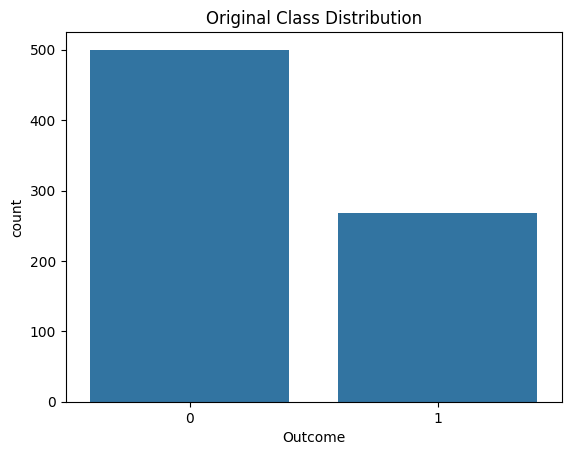

In [82]:
sns.countplot(x='Outcome', data=df)
plt.title("Original Class Distribution")
plt.show()

## Split Features & Target

In [83]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

## Apply SMOTE

In [84]:
smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X, y)

In [85]:
print(y.value_counts())
print(pd.Series(y_res).value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
1    500
0    500
Name: count, dtype: int64


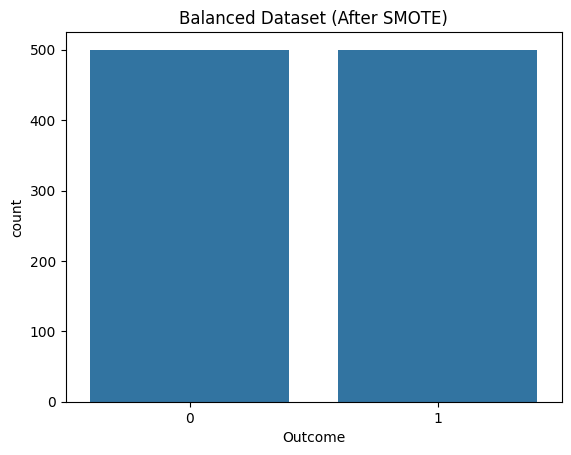

In [86]:
sns.countplot(x=y_res)
plt.title("Balanced Dataset (After SMOTE)")
plt.show()

## Split Features & Target

In [87]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

## Train-Test Split

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res,
    test_size=0.2,
    random_state=42,
    stratify=y_res
)

## Feature Scaling

In [90]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train Model

In [91]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## Prediction

In [92]:
y_pred = model.predict(X_test)

## Evaluate Model

In [93]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.815


In [94]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.78      0.81       100
           1       0.79      0.85      0.82       100

    accuracy                           0.81       200
   macro avg       0.82      0.81      0.81       200
weighted avg       0.82      0.81      0.81       200



## Confusion Matrix

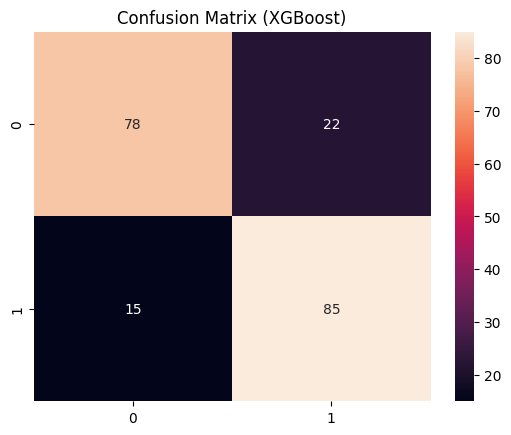

In [95]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (XGBoost)")
plt.show()

## Hyperparameter Tuning

In [97]:
param_grid = {
    'model__n_estimators': [300, 500],
    'model__max_depth': [4, 6, 8],
    'model__learning_rate': [0.01, 0.05],
    'model__subsample': [0.8, 1],
    'model__colsample_bytree': [0.8, 1]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 8, 'model__n_estimators': 300, 'model__subsample': 1}
Best CV Score: 0.80625


## Save Model

In [100]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))